## 1. Dataset

Задача полягає у тренування моделі детекції об'єктів на відкритому YOLO датасеті

**Датасет:** [VisDrone2019-DET](https://github.com/VisDrone/VisDrone-Dataset) аерознімки з дронів, 14 міст Китаю. Тематично близький до GIS систем, тому було прийнято рішення використовувати його.

**Чому VisDrone:** реальні міські сцени з висоти пташиного польоту, складність у малих об'єктах для визначення

Моделька YOLOv8n (nano) найлегша версія YOLOv8, локальне тренування на RTX 4050 під 6 GB VRAM


## 2. Аналіз датасету

Перед тренуванням перевіряємо, *з чим* працює модель: кількість даних, баланс класів, якість розмітки

#### 2.1 Підрахунок зображень

Рахуємо пари `image` до `label` у train/val/test. Колонка `match` відповідає, що кожному `.jpg` відповідає `.txt`

In [3]:
from pathlib import Path
import pandas as pd


ROOT = Path.cwd().resolve()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent

DATA_ROOT = ROOT / "data" / "datasets" / "VisDrone"

rows = []
for split in ["train", "val", "test"]:
    imgs = list((DATA_ROOT / "images" / split).glob("*.jpg"))
    lbls = list((DATA_ROOT / "labels" / split).glob("*.txt"))
    rows.append({
        "split": split,
        "images": len(imgs),
        "labels": len(lbls),
        "match": len(imgs) == len(lbls),
    })

df_splits = pd.DataFrame(rows)
display(df_splits)

,split,images,labels,match
0,train,6471,6471,True
1,val,548,548,True
2,test,1610,1610,True


#### 2.2 Таблиця класів та баланс

Парсинг YOLO-labels і підрахунок інстансів на класах. Графік показує дисбаланс (car >> tricycle)

,class_name,train,val,train_%
class_id,,,,
0,pedestrian,79337,8844,23.1%
1,people,27059,5125,7.9%
2,bicycle,10480,1287,3.1%
3,car,144867,14064,42.2%
4,van,24956,1975,7.3%
5,truck,12875,750,3.8%
6,tricycle,4812,1045,1.4%
7,awning-tricycle,3246,532,0.9%
8,bus,5926,251,1.7%


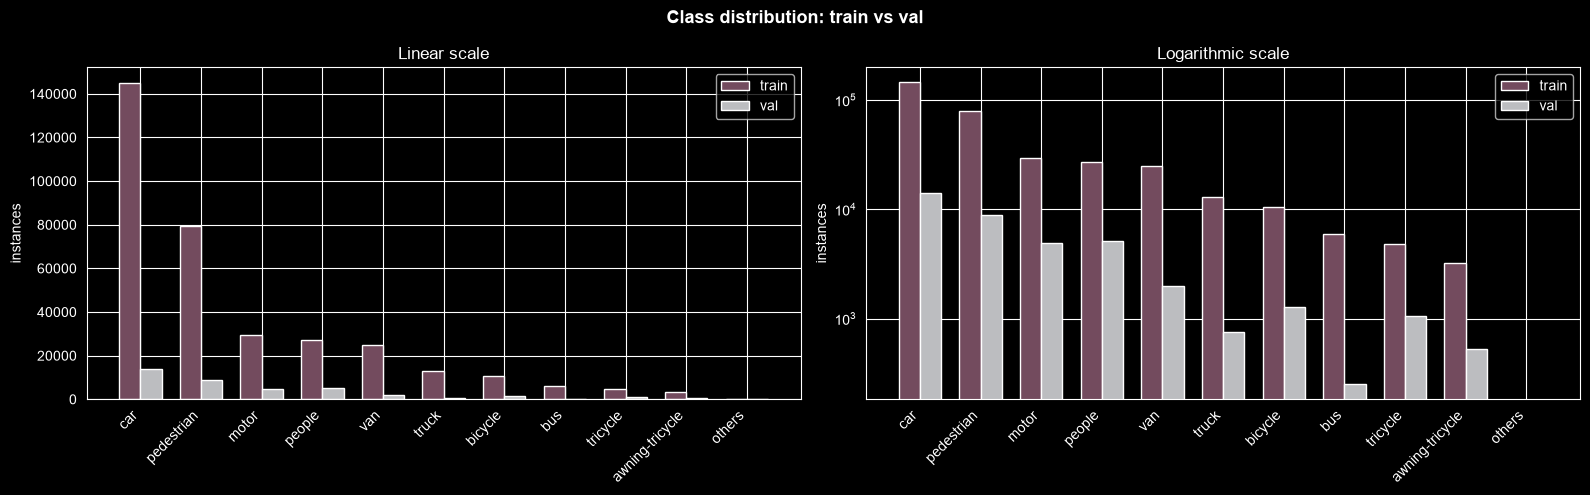

In [4]:
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

CLASS_NAMES = {
    0: "pedestrian", 1: "people", 2: "bicycle", 3: "car", 4: "van",
    5: "truck", 6: "tricycle", 7: "awning-tricycle", 8: "bus",
    9: "motor", 10: "others",
}


def count_classes(label_dir: Path) -> Counter:
    ids = [
        int(line.split()[0])
        for lbl_file in label_dir.glob("*.txt")
        for line in lbl_file.read_text().strip().splitlines()
        if line.strip()
    ]
    return Counter(ids)


train_counts = count_classes(DATA_ROOT / "labels" / "train")
val_counts = count_classes(DATA_ROOT / "labels" / "val")


df_classes = pd.DataFrame(index=list(CLASS_NAMES.keys()))
df_classes.index.name = "class_id"
df_classes["class_name"] = df_classes.index.map(CLASS_NAMES)
df_classes["train"] = df_classes.index.map(train_counts).fillna(0).astype(int)
df_classes["val"] = df_classes.index.map(val_counts).fillna(0).astype(int)
df_classes["train_%"] = (df_classes["train"] / df_classes["train"].sum() * 100).round(1)

styled_df = (
    df_classes
    .sort_index()
    .style
    .bar(subset=["train", "val"], color="#734B5E", vmin=0)
    .bar(subset=["train_%"], color="#BCBDC0", vmin=0, vmax=100)
    .format({"train_%": "{:.1f}%"})
)
display(styled_df)

df_sorted = df_classes.sort_values("train", ascending=False)
x = range(len(df_sorted))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, scale, title in zip(
    axes,
    ["linear", "log"],
    ["Linear scale", "Logarithmic scale"],
):
    ax.bar([i - width / 2 for i in x], df_sorted["train"], width, label="train", color="#734B5E")
    ax.bar([i + width / 2 for i in x], df_sorted["val"], width, label="val", color="#BCBDC0")
    ax.set_yscale(scale)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_sorted["class_name"], rotation=45, ha="right")
    ax.set_ylabel("instances")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Class distribution: train vs val", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Візуальна перевірка якості розмітки

Випадкова вибірка з train. Наклад bbox поверх зображень, щоб вручну оцінити якість анотацій.

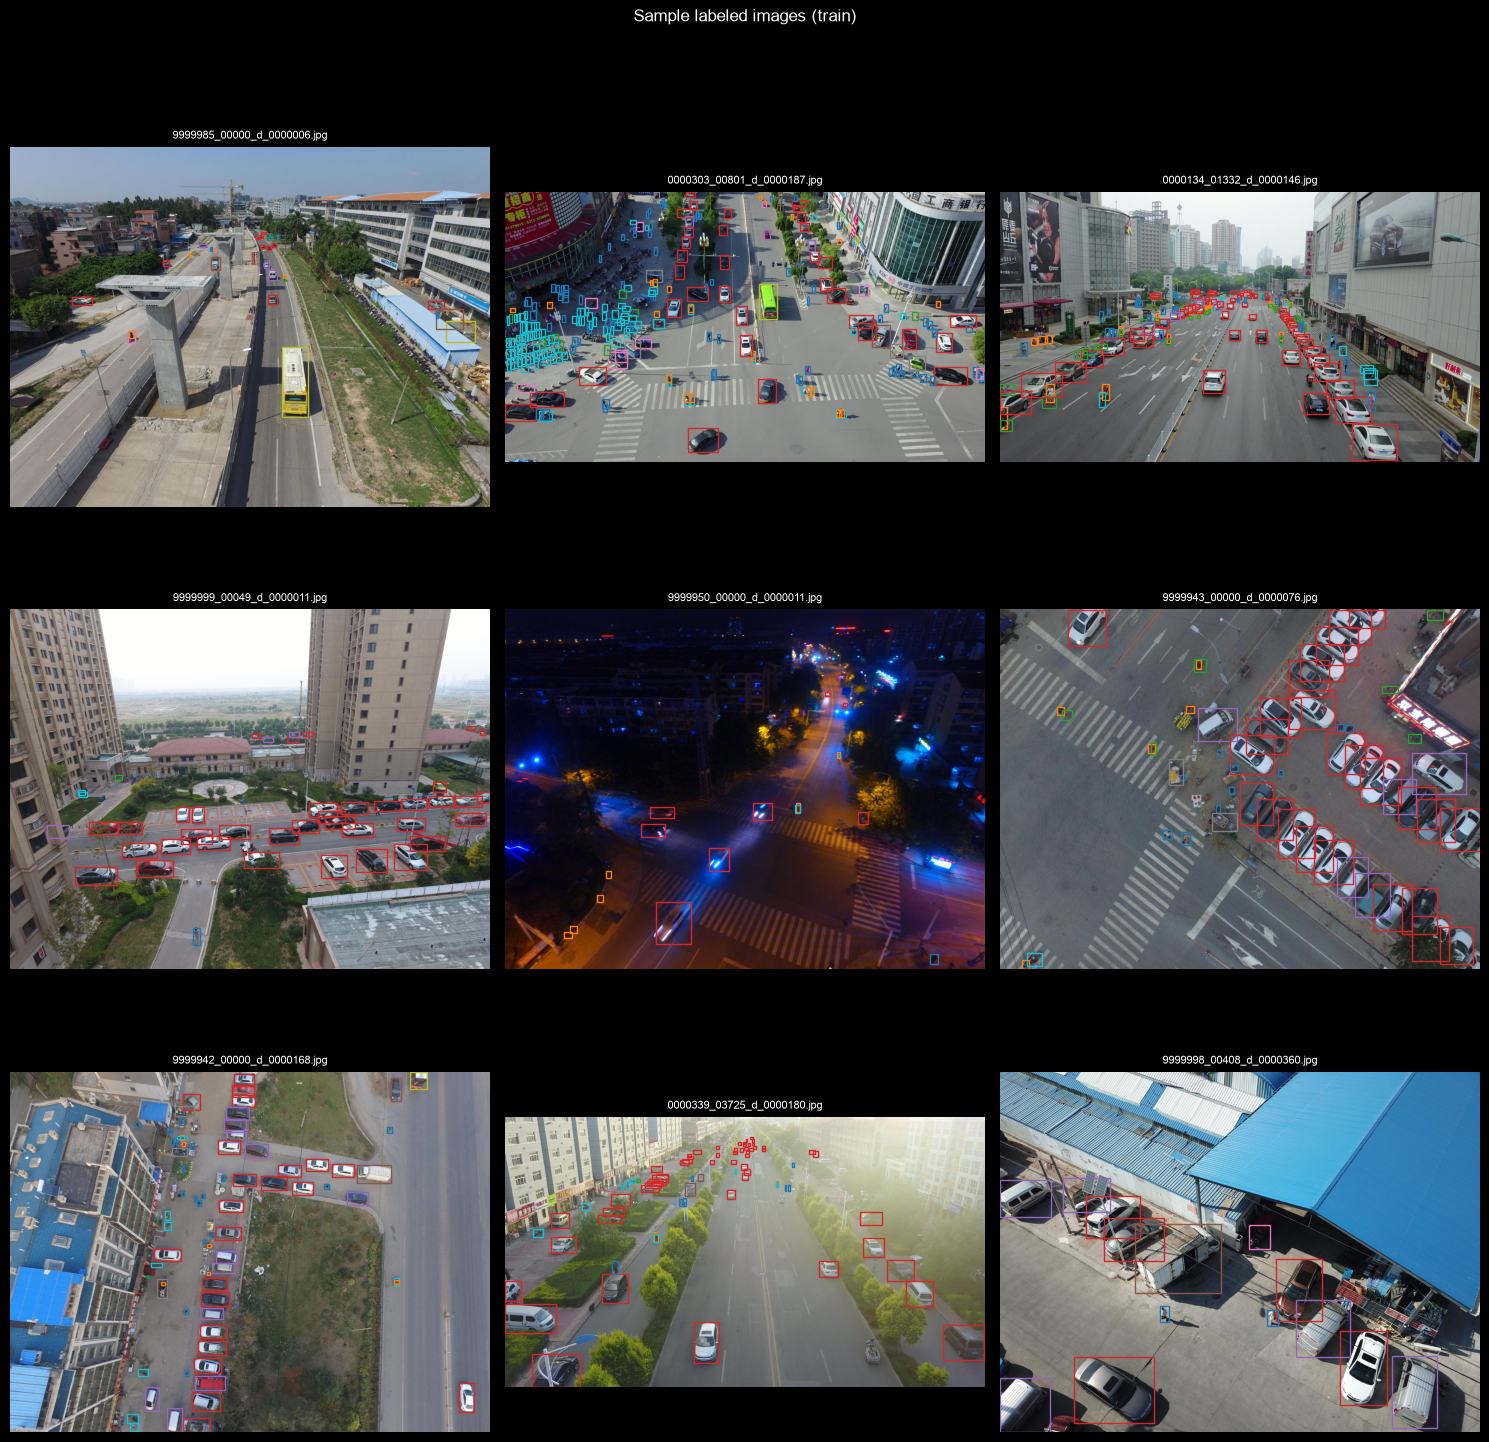

In [5]:
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_labeled_images(split="train", n=6, seed=42):
    img_dir = DATA_ROOT / "images" / split
    lbl_dir = DATA_ROOT / "labels" / split
    images = list(img_dir.glob("*.jpg"))
    random.seed(seed)
    samples = random.sample(images, min(n, len(images)))

    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    colors = plt.cm.tab10.colors
    for ax, img_path in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=8)

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                cls_id, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw*w, bh*h,
                    linewidth=1, edgecolor=colors[int(cls_id) % 10], facecolor="none"
                )
                ax.add_patch(rect)

    for ax in axes[len(samples):]:
        ax.axis("off")
    plt.suptitle(f"Sample labeled images ({split})", y=1.01)
    plt.tight_layout()
    plt.show()

show_labeled_images("train", n=9)

### 2.4 Розподіл розмірів bbox

Додатковий R&D-аналіз. На просторах інтернету пишуть, що VisDrone відомий дрібними об'єктами, отже дивлячись на нормалізовану площу bbox, якщо більшість маленькі, YOLOv8n на 640px може мати складнощі з recall

Mean bbox area: 0.0015
Median bbox area: 0.0005
Small objects (<0.01 area): 334475 (97.5%)


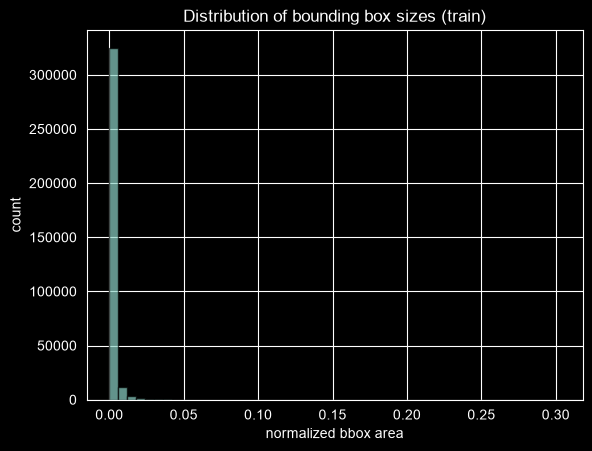

In [6]:
import numpy as np

areas = []
for lbl_file in (DATA_ROOT / "labels" / "train").glob("*.txt"):
    for line in lbl_file.read_text().strip().splitlines():
        _, _, _, bw, bh = map(float, line.split())
        areas.append(bw * bh)

areas = np.array(areas)
print(f"Mean bbox area: {areas.mean():.4f}")
print(f"Median bbox area: {np.median(areas):.4f}")
print(f"Small objects (<0.01 area): {(areas < 0.01).sum()} ({(areas < 0.01).mean()*100:.1f}%)")

plt.hist(areas, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("normalized bbox area")
plt.ylabel("count")
plt.title("Distribution of bounding box sizes (train)")
plt.show()

### Спостереження після EDA

1. **Розподіл split-ів.** у підрахунок кількість зображень (train / val / test)  і label-файлів повністю збігається. Це видно на пари image та label цілісні, дані готові до тренування;
2. **Баланс класів.** дисбаланс суттєво 'плаче'. Де `car` і `pedestrian` хоч якось відносно представлені, тоді як інші класи різко падають вниз (особливо видно на представлених графіках). Різниця між найчастішими та найрідкіснішими класами величезна;
3. Якість розмітки на візуалізації bbox досить добре обводить помітні об'єкти, анотації якісні. Однак дрібні деталі, які навіть людським оком ледь помітні, часто **відсутні в розмітці датасету**. Наприклад, кран на одному з кадрів не позначений як `others`;
4. **Розміри bbox:** близько 97.5% об'єктів дрібні. Це головний аргумент, чому small-object detection тут незвична задача;
5. **Гіпотеза для тренування:** модель, напевно, гірше працюватиме на маленьких об'єктах та на рідкісних класах (`tricycle`, `awning-tricycle`), де мало прикладів у train.